In [22]:
from pathlib import Path

import yaml
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

EXPERIMENTS_DIR = Path("../docs/experiments/")

def experiment_dataframe(experiment_name):
    experiment_dir = EXPERIMENTS_DIR / experiment_name
    
    # ---------------------------------------------------------
    # Load experiments
    # ---------------------------------------------------------
    
    experiment_files = sorted(
        experiment_dir.glob("*/experiment.yml")
    )
    
    experiments = []
    
    for path in experiment_files:
        with open(path, "r", encoding="utf-8") as f:
            experiment = yaml.safe_load(f)
    
        experiments.append({
            "id": experiment["id"],
            "name": experiment["name"],
            "mae_w": experiment["metrics"]["mae_w"],
            "relative_mae": experiment["metrics"]["relative_mae"],
            "rmse_w": experiment["metrics"]["rmse_w"],
            "git_commit": experiment["model"]["git_commit"],
        })
    
    
    results = pd.DataFrame(experiments)
    return results

def plot_experiment_evolutions(results, save_path = None, column = "relative_mae", ylabel = "relative mae", title = "Power Forecast Error Evolution"):
    # ---------------------------------------------------------
    # Calculate improvement relative to baseline
    # ---------------------------------------------------------
    baseline_mae = results.iloc[0][column]
    
    results["improvement_pct"] = (
        (baseline_mae - results[column])
        / baseline_mae
        * 100
    )
    
    
    # ---------------------------------------------------------
    # Plot
    # ---------------------------------------------------------
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    bars = ax.bar(
        results["name"],
        results[column],
    )
    
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Experiment")
    
    ax.tick_params(axis="x", rotation=20)
    
    # Add values above bars
    for bar, val in zip(bars, results[column]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.2f}",
            ha="center",
            va="bottom",
        )
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if save_path is not None:
        output_path = Path(save_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            output_path,
            bbox_inches="tight",
        )
    
    plt.tight_layout()
    plt.show()
    



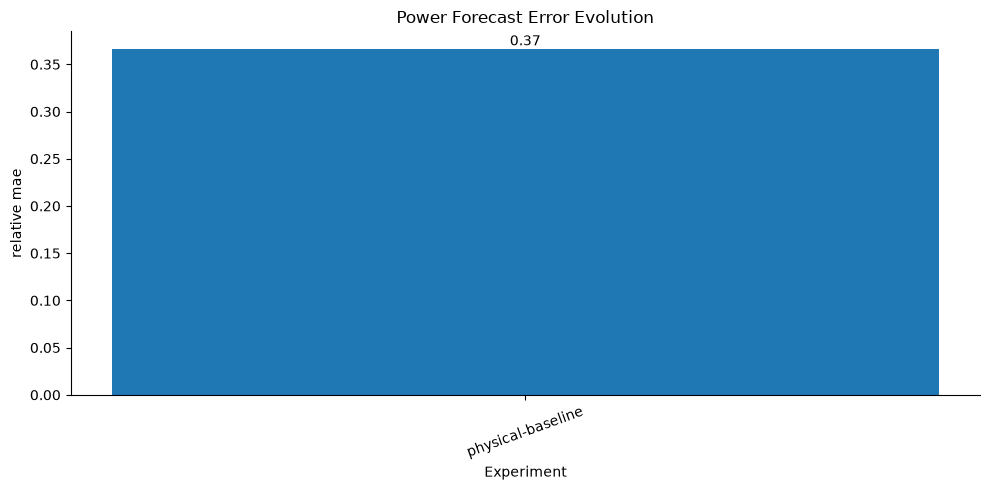

In [23]:
results = experiment_dataframe('pv_power_forecast')
plot_experiment_evolutions(results, save_path = "../docs/images/pv-power-forecast-error-evolution.svg")